# Task 1 - Data Merge & Product Recommendation Feature Engineering
**Andrew - Formative 2: Multimodal Data Preprocessing Assignment**

This notebook merges `customer_social_profiles` and `customer_transactions` into a single, model-ready, customer-level dataset for the **Product Recommendation Model** built in Task 4.

**Pipeline:**
1. Load the two source files
2. Exploratory Data Analysis (distributions, outliers, correlations)
3. Clean each source independently
4. Reconcile the two different customer ID schemes
5. Engineer RFM (Recency/Frequency/Monetary) and social-engagement features
6. Build a leakage-free prediction target
7. Merge everything into `merged_dataset.csv`


## 0. Setup & Upload Data
 Upload `customer_social_profiles.xlsx` and `customer_transactions.xlsx`

In [1]:
!pip install -q openpyxl

import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

IN_COLAB = 'google.colab' in sys.modules

SOCIAL_FILE = 'customer_social_profiles.xlsx'
TXN_FILE = 'customer_transactions.xlsx'

if IN_COLAB and not (os.path.exists(SOCIAL_FILE) and os.path.exists(TXN_FILE)):
    from google.colab import files
    print('Please upload customer_social_profiles.xlsx and customer_transactions.xlsx')
    uploaded = files.upload()


Please upload customer_social_profiles.xlsx and customer_transactions.xlsx


Saving customer_transactions.xlsx to customer_transactions.xlsx
Saving customer_social_profiles.xlsx to customer_social_profiles.xlsx


## 1. Load the Raw Data

In [2]:
social_raw = pd.read_excel(SOCIAL_FILE)
txn_raw = pd.read_excel(TXN_FILE)

print('customer_social_profiles:', social_raw.shape)
print('customer_transactions   :', txn_raw.shape)

social_raw.head()

customer_social_profiles: (155, 5)
customer_transactions   : (150, 6)


,customer_id_new,social_media_platform,engagement_score,purchase_interest_score,review_sentiment
0,A178,LinkedIn,74,4.9,Positive
1,A190,Twitter,82,4.8,Neutral
2,A150,Facebook,96,1.6,Positive
3,A162,Twitter,89,2.6,Positive
4,A197,Twitter,92,2.3,Neutral


In [3]:
txn_raw.head()

,customer_id_legacy,transaction_id,purchase_amount,purchase_date,product_category,customer_rating
0,151,1001,408,2024-01-01,Sports,2.3
1,192,1002,332,2024-01-02,Electronics,4.2
2,114,1003,442,2024-01-03,Electronics,2.1
3,171,1004,256,2024-01-04,Clothing,2.8
4,160,1005,64,2024-01-05,Clothing,1.3


In [4]:
print(social_raw.dtypes)
print()
print(txn_raw.dtypes)

customer_id_new             object
social_media_platform       object
engagement_score             int64
purchase_interest_score    float64
review_sentiment            object
dtype: object

customer_id_legacy             int64
transaction_id                 int64
purchase_amount                int64
purchase_date         datetime64[ns]
product_category              object
customer_rating              float64
dtype: object


## 2. Exploratory Data Analysis

Before cleaning, we look at missingness, duplicates, and the shape of the numeric distributions in both sources.

In [5]:
print('--- Missing values ---')
print('Social profiles:\n', social_raw.isna().sum())
print()
print('Transactions:\n', txn_raw.isna().sum())

print()
print('--- Duplicates ---')
print('Exact duplicate rows in social profiles:', social_raw.duplicated().sum())
print('Duplicate transaction_id:', txn_raw['transaction_id'].duplicated().sum())
print('Duplicate customer_id_new (expected — a customer can have multiple platforms):',
      social_raw['customer_id_new'].duplicated().sum())

--- Missing values ---
Social profiles:
 customer_id_new            0
social_media_platform      0
engagement_score           0
purchase_interest_score    0
review_sentiment           0
dtype: int64

Transactions:
 customer_id_legacy     0
transaction_id         0
purchase_amount        0
purchase_date          0
product_category       0
customer_rating       10
dtype: int64

--- Duplicates ---
Exact duplicate rows in social profiles: 5
Duplicate transaction_id: 0
Duplicate customer_id_new (expected — a customer can have multiple platforms): 71


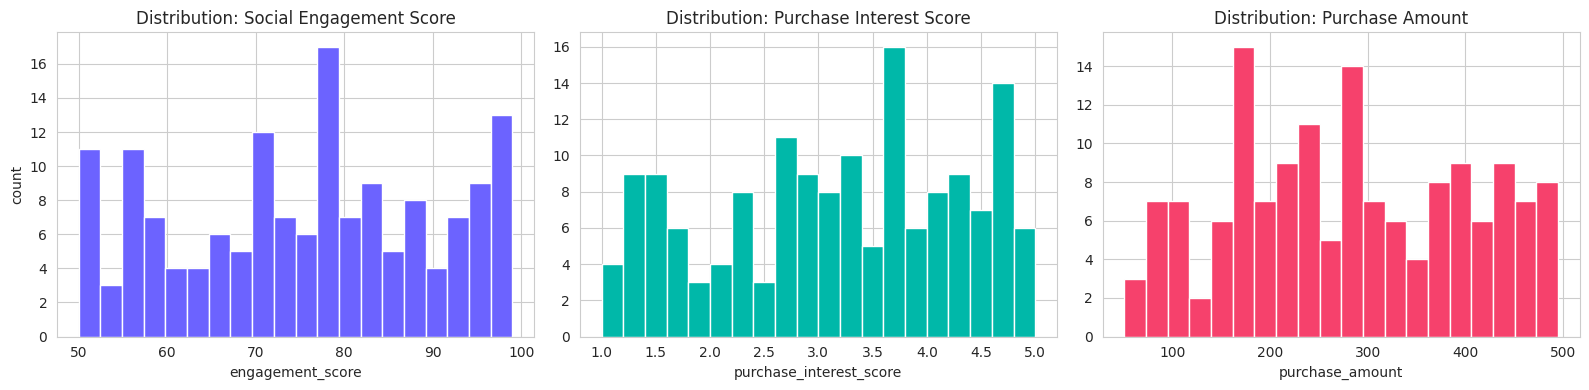

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(social_raw['engagement_score'], bins=20, color='#6C63FF', edgecolor='white')
axes[0].set_title('Distribution: Social Engagement Score')
axes[0].set_xlabel('engagement_score')
axes[0].set_ylabel('count')

axes[1].hist(social_raw['purchase_interest_score'], bins=20, color='#00B8A9', edgecolor='white')
axes[1].set_title('Distribution: Purchase Interest Score')
axes[1].set_xlabel('purchase_interest_score')

axes[2].hist(txn_raw['purchase_amount'], bins=20, color='#F6416C', edgecolor='white')
axes[2].set_title('Distribution: Purchase Amount')
axes[2].set_xlabel('purchase_amount')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2135/3668523622.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=txn_raw, x='product_category', y='purchase_amount', palette='Set2')


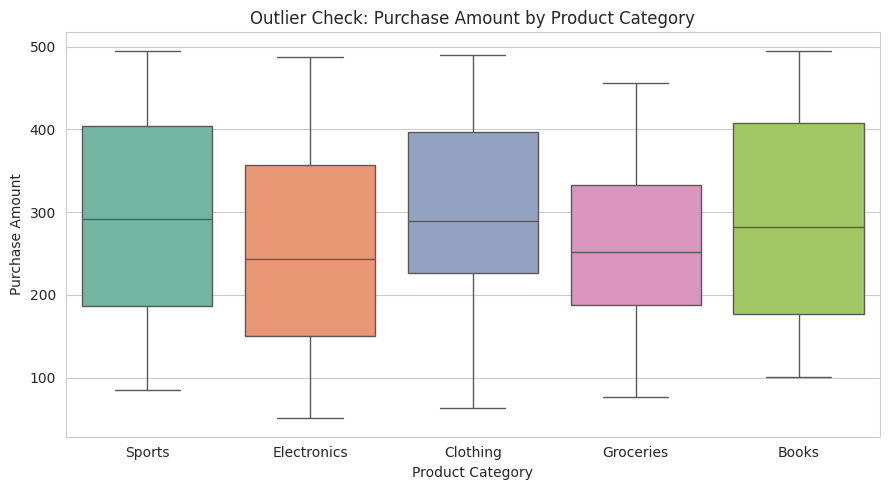

In [7]:
# Outlier check: purchase_amount by product_category
plt.figure(figsize=(9, 5))
sns.boxplot(data=txn_raw, x='product_category', y='purchase_amount', palette='Set2')
plt.title('Outlier Check: Purchase Amount by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Purchase Amount')
plt.tight_layout()
plt.show()

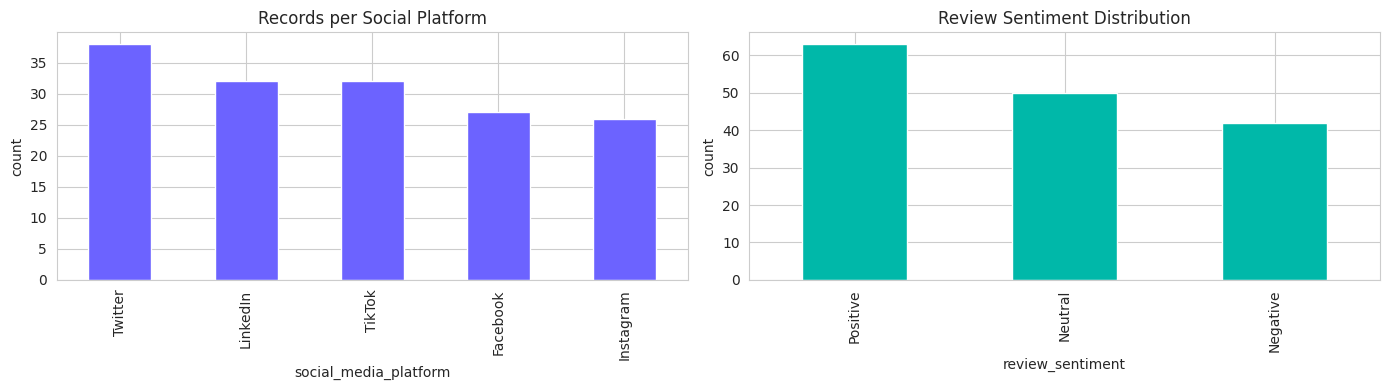

In [8]:
# Social platform popularity and sentiment mix -- helps decide how to
# aggregate multiple social rows per customer later
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

social_raw['social_media_platform'].value_counts().plot(kind='bar', ax=axes[0], color='#6C63FF')
axes[0].set_title('Records per Social Platform')
axes[0].set_ylabel('count')

social_raw['review_sentiment'].value_counts().plot(kind='bar', ax=axes[1], color='#00B8A9')
axes[1].set_title('Review Sentiment Distribution')
axes[1].set_ylabel('count')

plt.tight_layout()
plt.show()

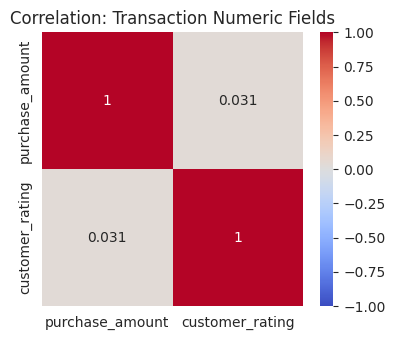

In [9]:
# Correlation among the raw numeric transaction fields
numeric_cols = ['purchase_amount', 'customer_rating']
corr = txn_raw[numeric_cols].corr()

plt.figure(figsize=(4, 3.5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation: Transaction Numeric Fields')
plt.tight_layout()
plt.show()

**EDA takeaways:**
- `customer_id_new` (social) and `customer_id_legacy` (transactions) use different formats (`"A178"` vs `178`) - these need to be reconciled before merging.
- Social profiles contain multiple rows per customer (one per platform they use), so they must be **aggregated to one row per customer** before merging.
- `customer_rating` has some missing values that need imputation.
- `purchase_amount` doesn't show extreme outliers beyond normal category-driven variation, so no aggressive outlier removal is needed - just standard cleaning.




## 3. Clean - `customer_social_profiles`

In [10]:
social = social_raw.drop_duplicates().copy()

# Reconcile ID schemes: "A178" -> 178 (int), matching customer_id_legacy in transactions
social['customer_id'] = social['customer_id_new'].str.extract(r'(\d+)').astype(int)

# Normalize categorical text
social['social_media_platform'] = social['social_media_platform'].str.strip().str.title()
social['review_sentiment'] = social['review_sentiment'].str.strip().str.title()

# Numeric sentiment score for averaging later
sentiment_map = {'Positive': 1, 'Neutral': 0, 'Negative': -1}
social['sentiment_score'] = social['review_sentiment'].map(sentiment_map)

# Defensive imputation (no gaps in the current file, but future data may have them)
for col in ['engagement_score', 'purchase_interest_score']:
    if social[col].isna().any():
        social[col] = social[col].fillna(social[col].median())

print('Cleaned social profiles:', social.shape, '| unique customers:', social['customer_id'].nunique())
social.head()

Cleaned social profiles: (150, 7) | unique customers: 84


,customer_id_new,social_media_platform,engagement_score,purchase_interest_score,review_sentiment,customer_id,sentiment_score
0,A178,Linkedin,74,4.9,Positive,178,1
1,A190,Twitter,82,4.8,Neutral,190,0
2,A150,Facebook,96,1.6,Positive,150,1
3,A162,Twitter,89,2.6,Positive,162,1
4,A197,Twitter,92,2.3,Neutral,197,0


### 3a. Aggregate social profiles to one row per customer
A customer can appear on several platforms, so we roll each customer's records up into a single feature set: average/peak engagement, average purchase interest, dominant sentiment, and how many platforms they're active on (a diversity signal).

In [11]:
def mode_or_nan(s):
    m = s.mode()
    return m.iloc[0] if not m.empty else np.nan

social_features = social.groupby('customer_id').agg(
    avg_engagement_score=('engagement_score', 'mean'),
    max_engagement_score=('engagement_score', 'max'),
    avg_purchase_interest_score=('purchase_interest_score', 'mean'),
    avg_sentiment_score=('sentiment_score', 'mean'),
    dominant_sentiment=('review_sentiment', mode_or_nan),
    primary_platform=('social_media_platform', mode_or_nan),
    platform_diversity=('social_media_platform', 'nunique'),
    social_record_count=('social_media_platform', 'count'),
).reset_index()

print(social_features.shape)
social_features.head()

(84, 9)


,customer_id,avg_engagement_score,max_engagement_score,avg_purchase_interest_score,avg_sentiment_score,dominant_sentiment,primary_platform,platform_diversity,social_record_count
0,100,77.000000,81,4.400000,-0.500000,Negative,Instagram,2,2
1,101,68.000000,68,1.000000,0.000000,Neutral,Twitter,1,1
2,102,51.000000,51,4.800000,0.000000,Neutral,Linkedin,1,1
3,103,64.333333,77,2.866667,0.333333,Positive,Instagram,2,3
4,104,83.000000,91,2.933333,-0.666667,Negative,Twitter,2,3


## 4. Clean - `customer_transactions`

In [12]:
txn = txn_raw.drop_duplicates(subset='transaction_id').copy()
txn = txn.rename(columns={'customer_id_legacy': 'customer_id'})
txn['product_category'] = txn['product_category'].str.strip().str.title()
txn['purchase_date'] = pd.to_datetime(txn['purchase_date'])

# Missing customer_rating -> impute with the median rating WITHIN the same
# product category (ratings can differ systematically by category)
txn['customer_rating'] = txn.groupby('product_category')['customer_rating'].transform(
    lambda s: s.fillna(s.median())
)
txn['customer_rating'] = txn['customer_rating'].fillna(txn['customer_rating'].median())

print('Cleaned transactions:', txn.shape, '| unique customers:', txn['customer_id'].nunique())
txn.head()

Cleaned transactions: (150, 6) | unique customers: 75


,customer_id,transaction_id,purchase_amount,purchase_date,product_category,customer_rating
0,151,1001,408,2024-01-01,Sports,2.3
1,192,1002,332,2024-01-02,Electronics,4.2
2,114,1003,442,2024-01-03,Electronics,2.1
3,171,1004,256,2024-01-04,Clothing,2.8
4,160,1005,64,2024-01-05,Clothing,1.3


## 5. Build a Leakage-Free Prediction Target

The goal is to predict the product category a customer will buy. If I build features from the *same* transaction I'm trying to predict, the model would be cheating. Instead:

1. Sort each customer's transactions chronologically.
2. Hold out the **most recent transaction's `product_category`** as the label (`target_product_category`).
3. Compute every transaction-derived feature using only that customer's **earlier** transactions.
4. Customers with fewer than 2 transactions are dropped - there's no history to learn from and/or no separate transaction to hold out as a label.

In [13]:
txn = txn.sort_values(['customer_id', 'purchase_date'])
txn_counts = txn.groupby('customer_id').size()
eligible_customers = txn_counts[txn_counts >= 2].index
txn = txn[txn['customer_id'].isin(eligible_customers)]

last_txn = txn.groupby('customer_id').tail(1).set_index('customer_id')
target = last_txn['product_category'].rename('target_product_category')

txn['_rank_from_end'] = txn.groupby('customer_id').cumcount(ascending=False)
history = txn[txn['_rank_from_end'] > 0].drop(columns='_rank_from_end').reset_index(drop=True)

print(f'Customers with >=2 transactions (usable for a leak-free target): {len(eligible_customers)}')
target.value_counts()

Customers with >=2 transactions (usable for a leak-free target): 45


,count
target_product_category,
Sports,13
Books,11
Clothing,10
Electronics,7
Groceries,4


## 6. Feature Engineering - Transaction / RFM Features
Classic **Recency, Frequency, Monetary** features, plus category-behavior signals, computed only from each customer's purchase *history* (not the held-out target transaction).

In [14]:
REFERENCE_DATE = txn_raw['purchase_date'].max() + pd.Timedelta(days=1)

def mode_or_nan2(s):
    m = s.mode()
    return m.iloc[0] if not m.empty else np.nan

txn_features = history.groupby('customer_id').agg(
    transaction_frequency=('transaction_id', 'count'),      # Frequency
    total_spend=('purchase_amount', 'sum'),                  # Monetary
    avg_purchase_amount=('purchase_amount', 'mean'),          # Monetary
    avg_customer_rating=('customer_rating', 'mean'),
    favorite_category=('product_category', mode_or_nan2),
    category_diversity=('product_category', 'nunique'),
    last_purchase_date=('purchase_date', 'max'),
    first_purchase_date=('purchase_date', 'min'),
).reset_index()

txn_features['recency_days'] = (REFERENCE_DATE - txn_features['last_purchase_date']).dt.days   # Recency
txn_features['customer_tenure_days'] = (
    txn_features['last_purchase_date'] - txn_features['first_purchase_date']
).dt.days
txn_features['purchase_cadence_days'] = (
    txn_features['customer_tenure_days'] / (txn_features['transaction_frequency'] - 1).replace(0, np.nan)
).fillna(txn_features['customer_tenure_days'])

txn_features = txn_features.drop(columns=['last_purchase_date', 'first_purchase_date'])

print(txn_features.shape)
txn_features.head()

(45, 10)


,customer_id,transaction_frequency,total_spend,avg_purchase_amount,avg_customer_rating,favorite_category,category_diversity,recency_days,customer_tenure_days,purchase_cadence_days
0,100,1,172,172.000000,4.000000,Clothing,1,38,0,0.0
1,101,3,871,290.333333,2.666667,Books,2,92,42,21.0
2,102,2,481,240.500000,3.800000,Electronics,1,106,31,31.0
3,103,2,635,317.500000,4.550000,Groceries,2,79,20,20.0
4,104,1,289,289.000000,1.500000,Clothing,1,28,0,0.0


## 7. Merge Social + Transaction Features + Target

In [15]:
merged = (
    social_features
    .merge(txn_features, on='customer_id', how='inner')
    .merge(target, on='customer_id', how='inner')
)

print('Merged shape (pre-encoding):', merged.shape)
merged.head()

Merged shape (pre-encoding): (36, 19)


,customer_id,avg_engagement_score,max_engagement_score,avg_purchase_interest_score,avg_sentiment_score,dominant_sentiment,primary_platform,platform_diversity,social_record_count,transaction_frequency,total_spend,avg_purchase_amount,avg_customer_rating,favorite_category,category_diversity,recency_days,customer_tenure_days,purchase_cadence_days,target_product_category
0,100,77.000000,81,4.400000,-0.500000,Negative,Instagram,2,2,1,172,172.000000,4.000000,Clothing,1,38,0,0.0,Books
1,101,68.000000,68,1.000000,0.000000,Neutral,Twitter,1,1,3,871,290.333333,2.666667,Books,2,92,42,21.0,Books
2,102,51.000000,51,4.800000,0.000000,Neutral,Linkedin,1,1,2,481,240.500000,3.800000,Electronics,1,106,31,31.0,Sports
3,103,64.333333,77,2.866667,0.333333,Positive,Instagram,2,3,2,635,317.500000,4.550000,Groceries,2,79,20,20.0,Sports
4,104,83.000000,91,2.933333,-0.666667,Negative,Twitter,2,3,1,289,289.000000,1.500000,Clothing,1,28,0,0.0,Clothing


An **inner join** is used deliberately - a customer only belongs in the final dataset if we have a social profile, enough transaction history to build features, *and* a held-out transaction to serve as the label. That's why the final row count is smaller than either source individually.

## 8. Post-Merge EDA: Correlations Across the Engineered Feature Set

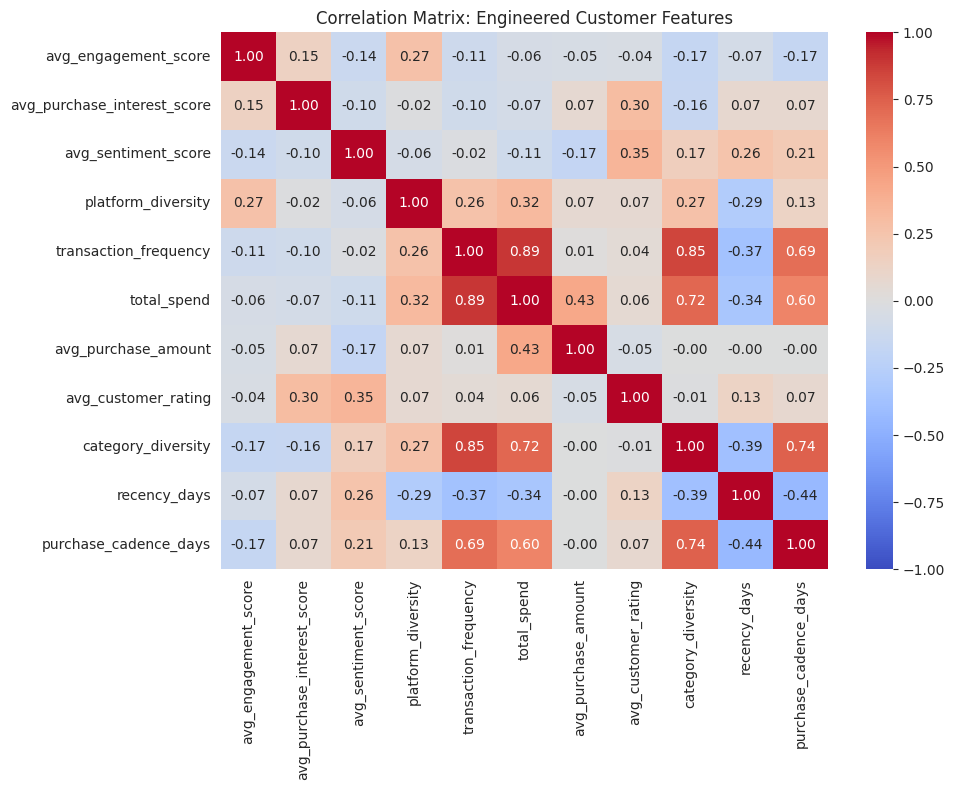

In [17]:
numeric_feature_cols = [
    'avg_engagement_score', 'avg_purchase_interest_score', 'avg_sentiment_score',
    'platform_diversity', 'transaction_frequency', 'total_spend',
    'avg_purchase_amount', 'avg_customer_rating', 'category_diversity',
    'recency_days', 'purchase_cadence_days'
]

plt.figure(figsize=(10, 8))
sns.heatmap(merged[numeric_feature_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix: Engineered Customer Features')
plt.tight_layout()
plt.show()

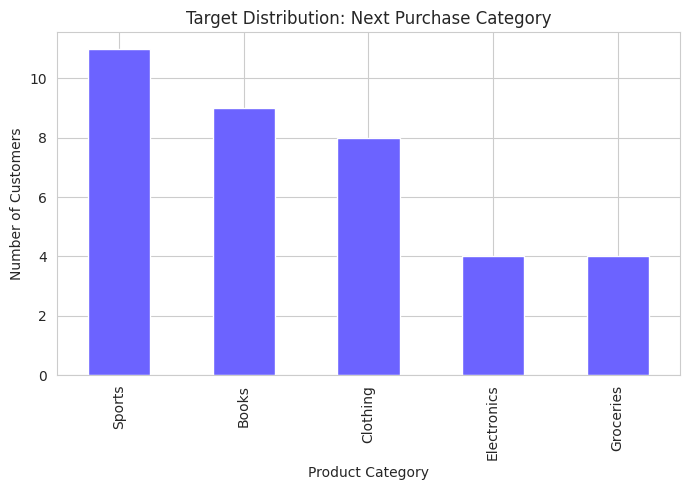

In [18]:
plt.figure(figsize=(7, 5))
merged['target_product_category'].value_counts().plot(kind='bar', color='#6C63FF')
plt.title('Target Distribution: Next Purchase Category')
plt.xlabel('Product Category')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

## 9. Encode Categorical Features

In [19]:
merged = pd.get_dummies(
    merged,
    columns=['primary_platform', 'dominant_sentiment', 'favorite_category'],
    prefix=['platform', 'sentiment', 'favorite_category'],
)
merged['target_product_category_encoded'] = merged['target_product_category'].astype('category').cat.codes

print('Final shape:', merged.shape)
merged.head()

Final shape: (36, 30)


,customer_id,avg_engagement_score,max_engagement_score,avg_purchase_interest_score,avg_sentiment_score,platform_diversity,social_record_count,transaction_frequency,total_spend,avg_purchase_amount,avg_customer_rating,category_diversity,recency_days,customer_tenure_days,purchase_cadence_days,target_product_category,platform_Facebook,platform_Instagram,platform_Linkedin,platform_Tiktok,platform_Twitter,sentiment_Negative,sentiment_Neutral,sentiment_Positive,favorite_category_Books,favorite_category_Clothing,favorite_category_Electronics,favorite_category_Groceries,favorite_category_Sports,target_product_category_encoded
0,100,77.000000,81,4.400000,-0.500000,2,2,1,172,172.000000,4.000000,1,38,0,0.0,Books,False,True,False,False,False,True,False,False,False,True,False,False,False,0
1,101,68.000000,68,1.000000,0.000000,1,1,3,871,290.333333,2.666667,2,92,42,21.0,Books,False,False,False,False,True,False,True,False,True,False,False,False,False,0
2,102,51.000000,51,4.800000,0.000000,1,1,2,481,240.500000,3.800000,1,106,31,31.0,Sports,False,False,True,False,False,False,True,False,False,False,True,False,False,4
3,103,64.333333,77,2.866667,0.333333,2,3,2,635,317.500000,4.550000,2,79,20,20.0,Sports,False,True,False,False,False,False,False,True,False,False,False,True,False,4
4,104,83.000000,91,2.933333,-0.666667,2,3,1,289,289.000000,1.500000,1,28,0,0.0,Clothing,False,False,False,False,True,True,False,False,False,True,False,False,False,1


## 10. Save `merged_dataset.csv`
This is the deliverable Task 4 (Model Integration) will load to train the Product Recommendation Model.

In [20]:
merged.to_csv('merged_dataset.csv', index=False)
print('Saved merged_dataset.csv with shape', merged.shape)

if IN_COLAB:
    from google.colab import files
    files.download('merged_dataset.csv')

Saved merged_dataset.csv with shape (36, 30)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 11. Summary

| Step | Result |
|---|---|
| Raw social profile rows | 155 (150 after removing 5 exact duplicates) |
| Raw transaction rows | 150 |
| Unique customers (social) | 84 |
| Unique customers (transactions) | 75 |
| Customers with ≥2 transactions (usable for a leak-free target) | 45 |
| **Final merged customers** | **36 rows** in `merged_dataset.csv` |
| Final feature count | **30 columns** in `merged_dataset.csv` (including target) |

**Key data quality issues handled:**
1. Two incompatible customer ID formats reconciled (`"A178"` ↔ `178`).
2. Social profiles de-duplicated and aggregated from multiple platform rows into one row per customer.
3. Missing `customer_rating` values imputed at the product-category level.
4. Target built without leakage — held-out most-recent transaction per customer, features built only from prior history.
5. Categorical fields one-hot encoded for direct use in Task 4's models (Random Forest / Logistic Regression / XGBoost).
